In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt


g = 9.8        
mc = 1.0       # Kocsi súly
mp = 0.1       # Rúd súly
l = 0.5        #Rúd hossz fele(így jönnek ki szépen a képletek)
dt = 0.01      


total_mass = mc + mp
polemass_length = mp * l
K = torch.randn(4, requires_grad=True)

In [2]:
def step(state, force):
    x, x_dot, theta, theta_dot = state

    costheta = torch.cos(theta)
    sintheta = torch.sin(theta)

    temp = (force + polemass_length * theta_dot**2 * sintheta) / total_mass

    theta_acc = (g * sintheta - costheta * temp) / (
        l * (4.0/3.0 - mp * costheta**2 / total_mass)
    )

    x_acc = temp - polemass_length * theta_acc * costheta / total_mass

    # Euler
    x = x + dt * x_dot
    x_dot = x_dot + dt * x_acc
    theta = theta + dt * theta_dot
    theta_dot = theta_dot + dt * theta_acc

    return torch.stack([x, x_dot, theta, theta_dot])

In [3]:
def controller(state, K):
    force = -torch.dot(K, state)
    return torch.clamp(force, -10, 10)

In [4]:
def simulate_with_K(K, steps=200):
    state = torch.tensor([0.0, 0.0, 0.1, 0.0])
    loss = 0.0

    for _ in range(steps):
        force = controller(state, K)
        state = step(state, force)

       
        loss += 10 * state[2]**2      #szög
        loss += 0.1 * state[0]**2     # pozició

    return loss

In [5]:
optimizer = torch.optim.Adam([K], lr=0.01)

for i in range(500):
    optimizer.zero_grad()
    
    loss = simulate_with_K(K)
    
    loss.backward()
    optimizer.step()

    if i % 50 == 0:
        print(f"{i}: loss={loss.item():.3f}, K={K.detach().numpy()}")

0: loss=20823.312, K=[-0.39158532 -0.7681428  -1.7103314   1.3002276 ]
50: loss=16178.701, K=[-0.92492104 -1.2577102  -1.2651079   1.5873164 ]
100: loss=14621.872, K=[-1.3084773 -1.5302246 -1.1208768  1.2793274]
150: loss=14114.627, K=[-1.4912792 -1.6844596 -1.0480134  1.0481843]
200: loss=14092.853, K=[-1.5496225 -1.7452654 -1.0223618  1.014452 ]
250: loss=14077.541, K=[-1.6012931 -1.7994764 -1.0047637  0.9934514]
300: loss=14060.995, K=[-1.6581806  -1.8594621  -0.98665005  0.9698434 ]
350: loss=14043.137, K=[-1.7200357 -1.9252656 -0.9679915  0.9446201]
400: loss=14024.199, K=[-1.7861636 -1.9960101 -0.9501762  0.9164714]
450: loss=14004.085, K=[-1.8572003  -2.0734901  -0.93083453  0.8905642 ]


In [6]:
def simulate(K, steps=500):
    state = torch.tensor([0.0, 0.0, 0.1, 0.0])
    history = []

    for _ in range(steps):
        force = controller(state, K)
        state = step(state, force)
        history.append(state.detach().numpy())

    return np.array(history)

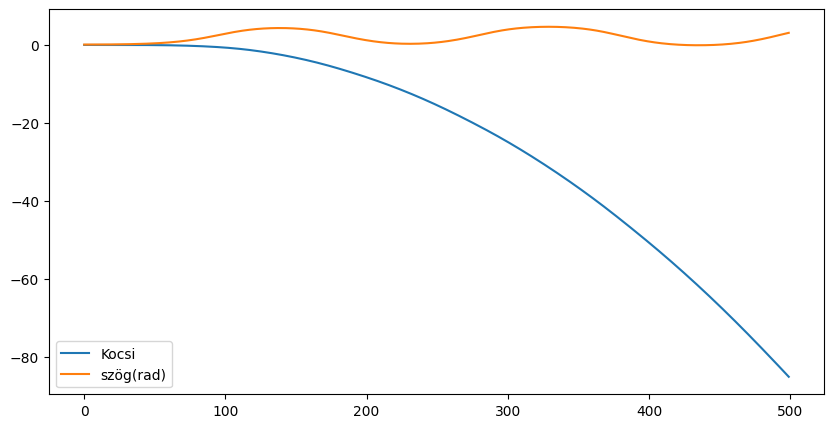

In [7]:
history = simulate(K)

plt.figure(figsize=(10,5))
plt.plot(history[:,0], label="Kocsi")
plt.plot(history[:,2], label="szög(rad)")
plt.legend()
plt.show()